In [1]:
#imports and libraries
import numpy as np
import pandas as pd
import joblib as jl
import sys
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import cross_val_score,TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    root_mean_squared_error
)
from matplotlib import pyplot as plt
import seaborn as sb

sys.path.append("..")

In [2]:
train=pd.read_csv("../data/processed/trainPool.csv")
test=pd.read_csv("../data/processed/test.csv")

# xTrainScaledSmote=np.load("../data/processed/xtrain_scaled.npy")
# yTrainSeveritySmote=np.load("../data/processed/ytrain_severity.npy")

features = [

    "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
target = "cases"

xTrainPool=train[features]

xTestPool=test[features]
yTrainPool=train[target]

yTestPool=test[target]

In [3]:

def regressorEvaluation(model,xTest,yTest):

    predictions=model.predict(xTest)
    predictionsActual=np.expm1(predictions)
    meanSquareError=mean_squared_error(yTest, predictionsActual)
    r2=r2_score(yTest, predictionsActual)
    rootMeanSquareError=root_mean_squared_error(yTest, predictionsActual)
    meanAbsoluteError=mean_absolute_error(yTest, predictionsActual)
    print("The Model Performance metrics are:")
    print(f"R2 Score: {r2}")
    print(f"Mean Squared Error: {meanSquareError}")
    print(f"Root Mean Squared Error: {rootMeanSquareError}")
    print(f"Mean Absolute Error: {meanAbsoluteError}")

    return {
        "R2_Score": r2,
        "MeanSquaredError": meanSquareError,
        "RootMeanSquaredError": rootMeanSquareError,
        "MeanAbsoluteError": meanAbsoluteError
    }

In [6]:
#Linear Regression as baseline model
from sklearn.preprocessing import StandardScaler


yTrainPoolLog=np.log1p(yTrainPool)
yTestLog=np.log1p(yTestPool)

linearRegression=LinearRegression()

linearRegression.fit(xTrainPool,yTrainPoolLog)

linearEvaluations=regressorEvaluation(linearRegression,xTestPool,yTestPool)

timeCv=TimeSeriesSplit(n_splits=5)
cvScore=cross_val_score(linearRegression,xTrainPool,yTrainPoolLog,cv=timeCv,scoring='r2')

print(f"Cross Validation Average R2 Score: {cvScore.mean():.4f}")
print(f"Cross Validation R2 Scores Std: {cvScore.std():.4f}")
print(f"Mean: {cvScore.mean():.4f} ± {cvScore.std():.4f}")

#jl.dump( linearRegression,"../models/linear_baseline.pkl")

The Model Performance metrics are:
R2 Score: 0.2798903009422109
Mean Squared Error: 8.797034554712717
Root Mean Squared Error: 2.965979527021843
Mean Absolute Error: 2.0456478835822063
Cross Validation Average R2 Score: 0.7038
Cross Validation R2 Scores Std: 0.0713
Mean: 0.7038 ± 0.0713


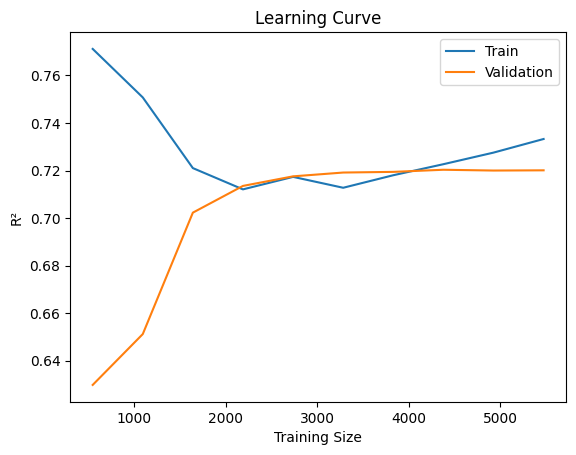

In [7]:
# helper function to evaluate the model accuracy for the regressors
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    linearRegression, xTrainPool, yTrainPoolLog, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, test_scores.mean(axis=1),   label='Validation')
plt.xlabel('Training Size')
plt.ylabel('R²')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [8]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np

tsCv = TimeSeriesSplit(n_splits=4)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost":          XGBRegressor(n_estimators=500, learning_rate=0.01, 
                                     max_depth=4, random_state=42, n_jobs=-1)
}

results = {}

for modelName, model in models.items():
    foldScores = []
    
    for foldNum, (trainIdx, valIdx) in enumerate(tsCv.split(xTrainPool), 1):
        # Slice this fold's data
        xFoldTrain, xFoldVal = xTrainPool.iloc[trainIdx], xTrainPool.iloc[valIdx]
        yFoldTrain, yFoldVal = yTrainPool.iloc[trainIdx], yTrainPool.iloc[valIdx]
        
        # Train and predict
        model.fit(xFoldTrain, yFoldTrain)
        preds = model.predict(xFoldVal)
        
        foldR2   = r2_score(yFoldVal, preds)
        foldRmse = root_mean_squared_error(yFoldVal, preds)
        foldScores.append({"fold": foldNum, "r2": foldR2, "rmse": foldRmse})
        foldmae=mean_absolute_error(yFoldVal,preds)
        foldmse=mean_squared_error(yFoldVal,preds)
        print(f"{modelName} | Fold {foldNum} → R²: {foldR2:.4f}  RMSE: {foldRmse:.2f}")
    
    meanR2   = np.mean([s["r2"]   for s in foldScores])
    meanRmse = np.mean([s["rmse"] for s in foldScores])
    print(f"{modelName} | Mean → R²: {meanR2:.4f}  RMSE: {meanRmse:.2f}\n")
    
    results[modelName] = foldScores

print(results)

LinearRegression | Fold 1 → R²: 0.7095  RMSE: 11.04
LinearRegression | Fold 2 → R²: 0.7132  RMSE: 10.86
LinearRegression | Fold 3 → R²: 0.7219  RMSE: 8.65
LinearRegression | Fold 4 → R²: 0.7169  RMSE: 10.10
LinearRegression | Mean → R²: 0.7154  RMSE: 10.16

RandomForest | Fold 1 → R²: 0.5999  RMSE: 12.96
RandomForest | Fold 2 → R²: 0.8075  RMSE: 8.90
RandomForest | Fold 3 → R²: 0.9157  RMSE: 4.76
RandomForest | Fold 4 → R²: 0.9496  RMSE: 4.26
RandomForest | Mean → R²: 0.8182  RMSE: 7.72

XGBoost | Fold 1 → R²: 0.5898  RMSE: 13.12
XGBoost | Fold 2 → R²: 0.7455  RMSE: 10.23
XGBoost | Fold 3 → R²: 0.8898  RMSE: 5.44
XGBoost | Fold 4 → R²: 0.9306  RMSE: 5.00
XGBoost | Mean → R²: 0.7889  RMSE: 8.45

{'LinearRegression': [{'fold': 1, 'r2': 0.709535933012523, 'rmse': 11.03893472222539}, {'fold': 2, 'r2': 0.7132311089704896, 'rmse': 10.863791590602457}, {'fold': 3, 'r2': 0.7219459029204547, 'rmse': 8.64760068965725}, {'fold': 4, 'r2': 0.7168928236411245, 'rmse': 10.097543081525922}], 'RandomFo

In [ ]:
from xgboost import XGBRegressor as xgBoostRegressor


featuresXg = [

    "district_encoded","T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
targetXg = "cases"

xTrainScaledXg=train[featuresXg]

xTestScaledXg=test[featuresXg]
yTrainXg=train[targetXg]

yTestXg=test[targetXg]

xgModel = xgBoostRegressor(
    learning_rate=0.01,    # slower learning
    n_estimators=1000,     # more trees to compensate
    max_depth=3,           # keep shallow
    subsample=0.8,         # add some randomness
    colsample_bytree=0.8,  # add some randomness
    min_child_weight=5,    # prevents overfitting on small groups
    random_state=42,
    n_jobs=-1
)

xgModel.fit(xTrainScaledXg, yTrainXg)
xgEvaluation=regressorEvaluation(xgModel, xTestScaledXg, yTestXg)
xgScores = cross_val_score(xgModel, xTrainScaledXg, yTrainXg, cv=tCsv, scoring='r2')
print(f"XGBoost CV R² scores: {xgScores.mean():.4f}")
print(f"Mean: {xgScores.mean():.4f} ± {xgScores.std():.4f}")

KeyError: "['water_proxy'] not in index"

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import RandomForestRegressor
# from xgboost import XGBRegressor
# from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error

# train = pd.read_csv("../data/processed/combinedTrained.csv")
# test  = pd.read_csv("../data/processed/test.csv")

# for df in [train, test]:
#     df["t1_log"]         = np.log1p(df["t1_cases"])
#     df["t2_log"]         = np.log1p(df["t2_cases"])
#     df["cases_momentum"] = df["t1_cases"] - df["t2_cases"]
#     df["log_cases"]      = np.log1p(df["cases"])

# features = [
#     "month_sin",       # strongest seasonal signal (perm=0.22)
#     "t1_log",          # log-scaled lag-1 cases (perm=0.16)
#     "t1_cases",        # raw lag-1 cases (perm=0.15)
#     "cases_momentum",  # t1 - t2: rising vs falling trend (perm=0.14)
#     "t2_cases",        # lag-2 cases (perm=0.07)
#     "t2_log",          # log-scaled lag-2 (perm=0.06)
#     "week_cos",        # residual weekly seasonality (perm=0.05)
# ]

# target = "cases"

# # ── log1p transform to handle right skew ──────────────────────────────────────
# train["log_cases"] = np.log1p(train[target])
# test["log_cases"]  = np.log1p(test[target])
# logTarget = "log_cases"

# # ── year-based walk-forward folds (fixes the mixed-year leakage) ───────────────
# # Each fold: train on all years up to year N-1, validate on year N
# foldDefs = [
#     ([2016],             2017),
#     ([2016, 2017],       2018),
#     ([2016, 2017, 2018], 2019),
#     ([2016, 2017, 2018,2019], 2020)
# ]

# models = {
#     "RandomForest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
#     "XGBoost":          XGBRegressor(n_estimators=500, learning_rate=0.01,
#                                      max_depth=4, random_state=42, n_jobs=-1)
# }

# results = {}

# for modelName, model in models.items():
#     foldScores = []

#     for foldNum, (trainYrs, valYr) in enumerate(foldDefs, 1):
#         trainMask = train["year"].isin(trainYrs)
#         valMask   = train["year"] == valYr

#         xFoldTrain = train.loc[trainMask, features]
#         yFoldTrain = train.loc[trainMask, logTarget]   # fit on log scale
#         xFoldVal   = train.loc[valMask,   features]
#         yFoldVal   = train.loc[valMask,   target]      # evaluate on original scale

#         model.fit(xFoldTrain, yFoldTrain)

#         logPreds = model.predict(xFoldVal)
#         preds    = np.expm1(logPreds)                  # invert log1p

#         foldR2   = r2_score(yFoldVal, preds)
#         foldRmse = root_mean_squared_error(yFoldVal, preds)
#         foldMae  = mean_absolute_error(yFoldVal, preds)
#         foldMse  = mean_squared_error(yFoldVal, preds)
#         foldScores.append({"fold": foldNum, "val_year": valYr,
#                            "r2": foldR2, "rmse": foldRmse,
#                            "mae": foldMae, "mse": foldMse})

#         print(f"{modelName} | Fold {foldNum} (val={valYr}) → "
#               f"R²: {foldR2:.4f}  RMSE: {foldRmse:.2f}  MAE: {foldMae:.2f}")

#     meanR2   = np.mean([s["r2"]   for s in foldScores])
#     meanRmse = np.mean([s["rmse"] for s in foldScores])
#     meanMae  = np.mean([s["mae"]  for s in foldScores])
#     print(f"{modelName} | Mean → R²: {meanR2:.4f}  RMSE: {meanRmse:.2f}  MAE: {meanMae:.2f}\n")

#     results[modelName] = foldScores

RandomForest | Fold 1 (val=2017) → R²: 0.8895  RMSE: 1.31  MAE: 0.62
RandomForest | Fold 2 (val=2018) → R²: 0.8889  RMSE: 1.49  MAE: 0.60
RandomForest | Fold 3 (val=2019) → R²: 0.2968  RMSE: 27.67  MAE: 9.96
RandomForest | Fold 4 (val=2020) → R²: 0.8813  RMSE: 1.20  MAE: 0.58
RandomForest | Mean → R²: 0.7391  RMSE: 7.92  MAE: 2.94

XGBoost | Fold 1 (val=2017) → R²: 0.7961  RMSE: 1.78  MAE: 0.87
XGBoost | Fold 2 (val=2018) → R²: 0.8092  RMSE: 1.95  MAE: 0.89
XGBoost | Fold 3 (val=2019) → R²: 0.2338  RMSE: 28.88  MAE: 10.74
XGBoost | Fold 4 (val=2020) → R²: 0.8106  RMSE: 1.52  MAE: 0.83
XGBoost | Mean → R²: 0.6624  RMSE: 8.53  MAE: 3.33



In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import RandomForestRegressor
# from xgboost import XGBRegressor
# from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error

# trainData = pd.read_csv("../data/processed/combinedTrained.csv")
# testData  = pd.read_csv("../data/processed/test.csv")
# train=pd.read_csv("../data/processed/trainPool.csv")

# for df in [trainData, testData, train]:
#     df.sort_values(["district_encoded", "year", "epi_week"], inplace=True)

#     # Rolling features — log-scaled only, no raw+log pairs
#     df["log_roll_mean_4w"] = np.log1p(
#         df.groupby("district_encoded")["cases"]
#           .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
#     )
#     df["log_roll_max_4w"] = np.log1p(
#         df.groupby("district_encoded")["cases"]
#           .transform(lambda x: x.shift(1).rolling(4, min_periods=1).max())
#     )

#     # Lag features — log-scaled only
#     df["t1_log"] = np.log1p(df["t1_cases"])

#     # Single directional signal
#     df["cases_momentum"] = df.groupby("district_encoded")["cases"].transform(
#         lambda x: x.shift(1) - x.shift(2)
#     )

#     df["log_cases"] = np.log1p(df["cases"])


# # ── Step 2: lean, non-redundant feature set ────────────────────────────────────
# modelFeatures = [
#     # Seasonality
#     "month_sin", "month_cos", "week_sin", "week_cos",

#     # District baseline
#     "district_encoded",

#     # Autoregressive signal — log only, no raw+log pairs
#     "t1_log",
#     "log_roll_mean_4w",
#     "log_roll_max_4w",

#     # Trend direction — single first derivative only
#     "cases_momentum",

#     # Weather — independent signal, restored from original features
#     "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "waterProxy",

#     # Outbreak flag
#     "isOutbreak",
# ]

# targetCol = "cases"
# logTargetCol = "log_cases"

# trainData["log_cases"] = np.log1p(trainData[targetCol])
# testData["log_cases"]  = np.log1p(testData[targetCol])
# train["log_cases"]     = np.log1p(train[targetCol])
# foldDefinitions = [
#     ([2016],                   2017),
#     ([2016, 2017],             2018),
#     ([2016, 2017, 2018],       2019),
#     ([2016, 2017, 2018, 2019], 2020)
# ]

# allModels = {
#     "RandomForest": RandomForestRegressor(
#         n_estimators=300, max_depth=12, min_samples_leaf=2,
#         random_state=42, n_jobs=-1
#     ),
#     "XGBoost": XGBRegressor(
#         n_estimators=500,
#         learning_rate=0.01,
#         max_depth=6,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=42,
#         n_jobs=-1,
#         early_stopping_rounds=30,
#     )
# }

# validationResults = {}

# for modelName, activeModel in allModels.items():
#     foldScores = []

#     for foldNum, (trainYears, valYear) in enumerate(foldDefinitions, 1):
#         trainMask = trainData["year"].isin(trainYears)
#         valMask   = trainData["year"] == valYear

#         xFoldTrain = trainData.loc[trainMask, modelFeatures]
#         yFoldTrain = trainData.loc[trainMask, logTargetCol]
#         xFoldVal   = trainData.loc[valMask,   modelFeatures]
#         yFoldVal   = trainData.loc[valMask,   targetCol]

#         if modelName == "XGBoost":
#             activeModel.fit(
#                 xFoldTrain, yFoldTrain,
#                 eval_set=[(xFoldTrain, yFoldTrain), (xFoldVal, trainData.loc[valMask, logTargetCol])],
#                 verbose=False
#             )
#             bestIteration = activeModel.best_iteration
#         else:
#             activeModel.fit(xFoldTrain, yFoldTrain)
#             bestIteration = None

#         logPredictions = activeModel.predict(xFoldVal)
#         finalPredictions = np.expm1(logPredictions)

#         foldR2   = r2_score(yFoldVal, finalPredictions)
#         foldRmse = root_mean_squared_error(yFoldVal, finalPredictions)
#         foldMae  = mean_absolute_error(yFoldVal, finalPredictions)
        
#         foldScores.append({
#             "fold": foldNum, "val_year": valYear,
#             "r2": foldR2, "rmse": foldRmse, "mae": foldMae,
#             "best_iter": bestIteration
#         })

#         print(f"{modelName} | Fold {foldNum} (val={valYear}) → "
#               f"R²: {foldR2:.4f}  RMSE: {foldRmse:.2f}  MAE: {foldMae:.2f}")

#     meanR2   = np.mean([score["r2"]   for score in foldScores])
#     meanRmse = np.mean([score["rmse"] for score in foldScores])
#     meanMae  = np.mean([score["mae"]  for score in foldScores])
#     print(f"{modelName} | Mean → R²: {meanR2:.4f}  RMSE: {meanRmse:.2f}  MAE: {meanMae:.2f}\n")

#     validationResults[modelName] = foldScores

RandomForest | Fold 1 (val=2017) → R²: 0.8929  RMSE: 1.29  MAE: 0.66
RandomForest | Fold 2 (val=2018) → R²: 0.9116  RMSE: 1.33  MAE: 0.60
RandomForest | Fold 3 (val=2019) → R²: 0.2752  RMSE: 28.09  MAE: 10.13
RandomForest | Fold 4 (val=2020) → R²: 0.8972  RMSE: 1.12  MAE: 0.63
RandomForest | Mean → R²: 0.7442  RMSE: 7.96  MAE: 3.00

XGBoost | Fold 1 (val=2017) → R²: 0.9232  RMSE: 1.09  MAE: 0.62
XGBoost | Fold 2 (val=2018) → R²: 0.9221  RMSE: 1.25  MAE: 0.58
XGBoost | Fold 3 (val=2019) → R²: 0.2360  RMSE: 28.84  MAE: 10.41
XGBoost | Fold 4 (val=2020) → R²: 0.8958  RMSE: 1.13  MAE: 0.64
XGBoost | Mean → R²: 0.7443  RMSE: 8.08  MAE: 3.06



In [ ]:
# print("=" * 60)
# print("TRAINING FINAL MODELS ON FULL DATA (2016-2019)")

# xTrainFull = train[modelFeatures]
# yTrainLogFull = train[logTargetCol]

# rfFinal = RandomForestRegressor(
#     n_estimators=300, max_depth=8, min_samples_leaf=6,
#     random_state=42, n_jobs=-1
# )
# rfFinal.fit(xTrainFull, yTrainLogFull)

# xgbBestIters = [score["best_iter"] for score in validationResults["XGBoost"] if score["best_iter"] is not None]
# avgBestIter = int(np.mean(xgbBestIters)) if xgbBestIters else 500
# print(f"XGBoost average best iteration: {avgBestIter}")

# xgbFinal = XGBRegressor(
#     n_estimators=avgBestIter,
#     learning_rate=0.01, max_depth=4,
#     subsample=0.8, colsample_bytree=0.8,
#     random_state=42, n_jobs=-1
# )
# xgbFinal.fit(xTrainFull, yTrainLogFull)

# xTestData = testData[modelFeatures]
# yTestData = testData[targetCol]

# for modelName, activeModel in [("RandomForest", rfFinal), ("XGBoost", xgbFinal)]:
#     logPredictions = activeModel.predict(xTestData)
#     finalPredictions = np.expm1(logPredictions)
    
#     print(f"\n{modelName} | TEST SET 2020")
#     print(f"  R²:   {r2_score(yTestData, finalPredictions):.4f}")
#     print(f"  RMSE: {root_mean_squared_error(yTestData, finalPredictions):.2f}")
#     print(f"  MAE:  {mean_absolute_error(yTestData, finalPredictions):.2f}")
#     testData[f"{modelName}Pred"] = finalPredictions

TRAINING FINAL MODELS ON FULL DATA (2016-2019)
XGBoost average best iteration: 476

RandomForest | TEST SET 2020
  R²:   0.9158
  RMSE: 1.01
  MAE:  0.56

XGBoost | TEST SET 2020
  R²:   0.9227
  RMSE: 0.97
  MAE:  0.59


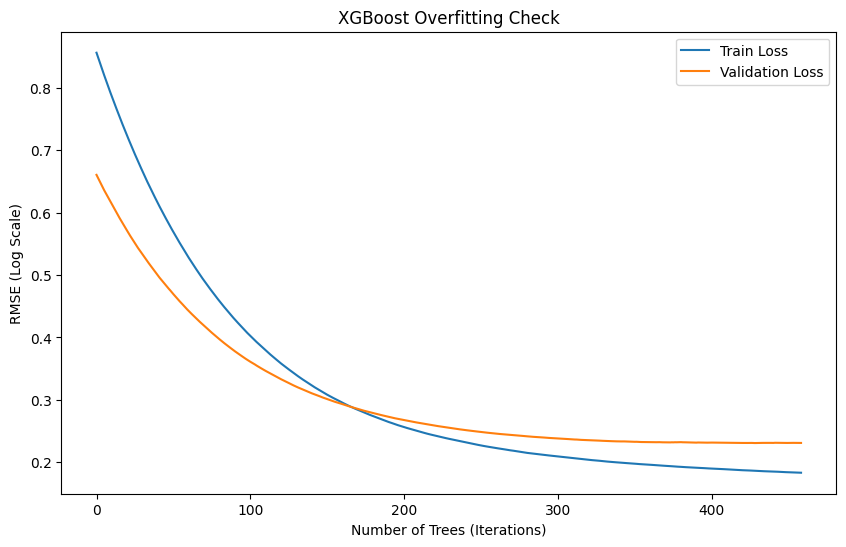

In [ ]:
# import matplotlib.pyplot as plt

# # We need to re-fit slightly to capture the history
# # Using the parameters from your previous cell
# xgbModel = XGBRegressor(
#     n_estimators=500,
#     learning_rate=0.01,
#     max_depth=4,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     early_stopping_rounds=30
# )

# # Fit with both train and validation sets
# xgbModel.fit(
#     xFoldTrain, yFoldTrain,
#     eval_set=[(xFoldTrain, yFoldTrain), (xFoldVal, trainData.loc[valMask, logTargetCol])],
#     verbose=False
# )

# # Retrieve performance metrics
# results = xgbModel.evals_result()
# epochs = len(results['validation_0']['rmse'])
# xAxis = range(0, epochs)

# # Plotting
# plt.figure(figsize=(10, 6))
# plt.plot(xAxis, results['validation_0']['rmse'], label='Train Loss')
# plt.plot(xAxis, results['validation_1']['rmse'], label='Validation Loss')
# plt.legend()
# plt.ylabel('RMSE (Log Scale)')
# plt.xlabel('Number of Trees (Iterations)')
# plt.title('XGBoost Overfitting Check')
# plt.show()

In [ ]:
# trainR2 = r2_score(yTrainLogFull, rfFinal.predict(xTrainFull))
# testR2 = r2_score(yTestData, rfFinal.predict(xTestData))

# print(f"Train R²: {trainR2:.4f} | Test R²: {testR2:.4f}")

Train R²: 0.9638 | Test R²: -0.0904


In [ ]:
# from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import RandomForestRegressor
# from xgboost import XGBRegressor
# import joblib
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
# import numpy as np

# tsCv = TimeSeriesSplit(n_splits=3)

# models = {
#     "RandomForest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
#     "XGBoost":          XGBRegressor(
#         n_estimators=500, learning_rate=0.01, max_depth=4,
#         random_state=42, n_jobs=-1
#     )
# }

# results = {}

# for modelName, model in models.items():
#     foldScores = []
    
#     for foldNum, (trainIdx, valIdx) in enumerate(tsCv.split(xTrainPool), 1):
#         xFoldTrain, xFoldVal = xTrainPool.iloc[trainIdx], xTrainPool.iloc[valIdx]
#         yFoldTrain, yFoldVal = yTrainPool.iloc[trainIdx], yTrainPool.iloc[valIdx]
        
#         model.fit(xFoldTrain, yFoldTrain)
        
#         # --- Predictions on BOTH train and val ---
#         trainPreds = model.predict(xFoldTrain)
#         valPreds   = model.predict(xFoldVal)
        
#         # --- Training metrics ---
#         trainR2   = r2_score(yFoldTrain, trainPreds)
#         trainRmse = root_mean_squared_error(yFoldTrain, trainPreds)
#         trainMae  = mean_absolute_error(yFoldTrain, trainPreds)
#         trainMse  = mean_squared_error(yFoldTrain, trainPreds)
        
#         # --- Validation metrics ---
#         valR2   = r2_score(yFoldVal, valPreds)
#         valRmse = root_mean_squared_error(yFoldVal, valPreds)
#         valMae  = mean_absolute_error(yFoldVal, valPreds)
#         valMse  = mean_squared_error(yFoldVal, valPreds)
        
#         # --- Overfitting gaps (train - val) ---
#         # Positive gap = model performs better on train than val = overfitting signal
#         gapR2   = trainR2 - valR2
#         gapRmse = trainRmse - valRmse   # usually negative if overfitting; use abs if preferred
#         gapMae  = trainMae - valMae
#         gapMse  = trainMse - valMse
        
#         foldScores.append({
#             "fold": foldNum,
#             "train_r2": trainR2, "train_rmse": trainRmse, "train_mae": trainMae, "train_mse": trainMse,
#             "val_r2":   valR2,   "val_rmse":   valRmse,   "val_mae":   valMae,   "val_mse":   valMse,
#             "gap_r2":   gapR2,   "gap_rmse":   gapRmse,   "gap_mae":   gapMae,   "gap_mse":   gapMse,
#         })
        
#         # Print per-fold comparison
#         print(f"\n{modelName} | Fold {foldNum}")
#         print(f"  Train → R²: {trainR2:.4f}  RMSE: {trainRmse:.2f}  MAE: {trainMae:.2f}  MSE: {trainMse:.2f}")
#         print(f"  Val   → R²: {valR2:.4f}  RMSE: {valRmse:.2f}  MAE: {valMae:.2f}  MSE: {valMse:.2f}")
#         print(f"  Gap   → R²: {gapR2:.4f}  RMSE: {gapRmse:.2f}  MAE: {gapMae:.2f}  MSE: {gapMse:.2f}")
        
#         # Simple overfitting flag
#         if gapR2 > 0.15 or (trainR2 > 0.95 and valR2 < 0.70):
#             print(f"  ⚠️  Potential overfitting detected on Fold {foldNum}!")
    
#     # --- Aggregate means ---
#     meanTrainR2   = np.mean([s["train_r2"]   for s in foldScores])
#     meanValR2     = np.mean([s["val_r2"]     for s in foldScores])
#     meanGapR2     = np.mean([s["gap_r2"]     for s in foldScores])
    
#     meanTrainRmse = np.mean([s["train_rmse"] for s in foldScores])
#     meanValRmse   = np.mean([s["val_rmse"]   for s in foldScores])
    
#     meanTrainMae  = np.mean([s["train_mae"]  for s in foldScores])
#     meanValMae    = np.mean([s["val_mae"]    for s in foldScores])
    
#     print(f"\n{'='*50}")
#     print(f"{modelName} | AVERAGES ACROSS {tsCv.n_splits} FOLDS")
#     print(f"  Train → R²: {meanTrainR2:.4f}  RMSE: {meanTrainRmse:.2f}  MAE: {meanTrainMae:.2f}")
#     print(f"  Val   → R²: {meanValR2:.4f}  RMSE: {meanValRmse:.2f}  MAE: {meanValMae:.2f}")
#     print(f"  Gap   → R²: {meanGapR2:.4f}")
#     print(f"{'='*50}\n")
    
#     results[modelName] = foldScores

# print(results)


RandomForest | Fold 1
  Train → R²: 0.9644  RMSE: 3.40  MAE: 0.97  MSE: 11.58
  Val   → R²: 0.8074  RMSE: 9.04  MAE: 2.48  MSE: 81.77
  Gap   → R²: 0.1569  RMSE: -5.64  MAE: -1.51  MSE: -70.18
  ⚠️  Potential overfitting detected on Fold 1!

RandomForest | Fold 2
  Train → R²: 0.9748  RMSE: 3.07  MAE: 0.75  MSE: 9.45
  Val   → R²: 0.9154  RMSE: 4.25  MAE: 1.37  MSE: 18.05
  Gap   → R²: 0.0594  RMSE: -1.17  MAE: -0.63  MSE: -8.59

RandomForest | Fold 3
  Train → R²: 0.9834  RMSE: 2.31  MAE: 0.56  MSE: 5.33
  Val   → R²: 0.9481  RMSE: 4.16  MAE: 1.39  MSE: 17.30
  Gap   → R²: 0.0353  RMSE: -1.85  MAE: -0.83  MSE: -11.97

RandomForest | AVERAGES ACROSS 3 FOLDS
  Train → R²: 0.9742  RMSE: 2.93  MAE: 0.76
  Val   → R²: 0.8903  RMSE: 5.82  MAE: 1.75
  Gap   → R²: 0.0839


XGBoost | Fold 1
  Train → R²: 0.9693  RMSE: 3.16  MAE: 1.54  MSE: 9.98
  Val   → R²: 0.7883  RMSE: 9.48  MAE: 2.74  MSE: 89.88
  Gap   → R²: 0.1810  RMSE: -6.32  MAE: -1.19  MSE: -79.90
  ⚠️  Potential overfitting detecte